#### R2P Program Unit 3: Lesson 1
# Introduction to Transpilation 

In this notebook, we explore the process of *transpilation* in Qiskit, which converts a quantum circuit into an optimized version tailored for a specific quantum backend. This includes mapping to native gate sets, reducing circuit depth, and improving execution efficiency. We will demonstrate how different optimization levels affect the transpiled circuit and discuss why these steps are crucial for running circuits on real quantum hardware.

## Defining the backend

In [32]:
from qiskit_ibm_runtime import QiskitRuntimeService

# Choose a real backend
service = QiskitRuntimeService(channel='ibm_quantum_platform',)
backend = service.least_busy(min_num_qubits=156)
# print backend details
print(
    f"Name: {backend.name}\n"
    f"Version: {backend.backend_version}\n"
    f"No. of qubits: {backend.num_qubits}\n"
    f"Processor type: {backend.processor_type}\n"
)

Name: ibm_pittsburgh
Version: 1.0.16
No. of qubits: 156
Processor type: {'family': 'Heron', 'revision': '3'}



## 1. Definition of the Problem


To illustrate different aspects of transpilation using Qiskit, we will use a graph-based example. Specifically, we consider the *Barabási–Albert graph*, a model that generates scale-free networks where nodes are added with preferential attachment mechanism in which new nodes are more likely to connect to existing nodes with higher degrees of connectivity. This creates a structure similar to many real-world networks including the Internet, the World Wide Web, and citation networks.


### Graph definition

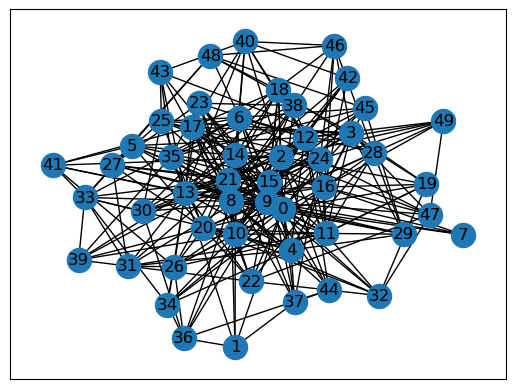

In [33]:
from networkx import barabasi_albert_graph, draw_networkx

n_nodes = 50
graph   = barabasi_albert_graph(n    = n_nodes, 
                                m    = 7, 
                                seed = 42)

draw_networkx(graph, with_labels=True)

We can build the Hamiltonian that this graph represents:

In [34]:
from utils import build_max_cut_paulis
from qiskit.quantum_info import SparsePauliOp

local_correlators = build_max_cut_paulis(graph)
cost_operator     = SparsePauliOp.from_list(local_correlators)
num_qubits        = cost_operator.num_qubits
print('Number of qubits in operator (Hamiltonian): ', num_qubits)
print('\Decomposed Operator (Each term of the Sum)\n')
print(f'Number of terms in operator {len(cost_operator)}\n')
print('Full operator:')
for n, oo in enumerate(cost_operator):
    print(f'        Operator {n}',oo)

Number of qubits in operator (Hamiltonian):  50
\Decomposed Operator (Each term of the Sum)

Number of terms in operator 301

Full operator:
        Operator 0 SparsePauliOp(['IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIZZ'],
              coeffs=[1.+0.j])
        Operator 1 SparsePauliOp(['IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIZIZ'],
              coeffs=[1.+0.j])
        Operator 2 SparsePauliOp(['IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIZIIZ'],
              coeffs=[1.+0.j])
        Operator 3 SparsePauliOp(['IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIZIIIZ'],
              coeffs=[1.+0.j])
        Operator 4 SparsePauliOp(['IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIZIIIIZ'],
              coeffs=[1.+0.j])
        Operator 5 SparsePauliOp(['IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIZIIIIIZ'],
              coeffs=[1.+0.j])
        Operator 6 SparsePauliOp(['IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIZIIIIIIZ'],
              coeffs=[1.+0.j])
        Operator 7 

### Ansatz (circuit)


To solve our graph problem using a quantum computer, we first map it to an Ising Hamiltonian, as we just did. This transforms the classical optimization task into a quantum ground state search, where the solution corresponds to the lowest energy state of the Hamiltonian.

One interesting algorithm for finding this ground state is the *Quantum Approximate Optimization Algorithm (QAOA)*. QAOA is a variational quantum algorithm that alternates between two Hamiltonians: a mixer (with a known ground state) and a cost Hamiltonian that encodes the problem. By tuning parameters across layers, the algorithm guides the system toward the optimal solution.

QAOA is known for its adaptability and relatively shallow circuit depth, making it suitable for near-term quantum devices. For a deeper dive, check this [tutorial](https://learning.quantum.ibm.com/tutorial/quantum-approximate-optimization-algorithm) and the [Utility-scale QAOA](https://quantum.cloud.ibm.com/learning/en/courses/quantum-computing-in-practice/utility-scale-qaoa) course from quantum computing in practice series.

Now we will construct the cost Hamiltonian circuit for our example, which maps to a 50-qubit QAOA circuit. Then, we will use [`QAOAAnsatz`](https://docs.quantum.ibm.com/api/qiskit/qiskit.circuit.library.QAOAAnsatz) function in Qiskit to build the full QAOA circuit. 

In [35]:
from qiskit import QuantumCircuit
from qiskit.circuit.library import QAOAAnsatz

# We are taking advantage of the QAOAAnsatz class to build the cost layer, 
# note that we are giving it dummy initial state and mixer circuits.

dummy_initial_state  = QuantumCircuit(num_qubits)  # the real initial state is defined later
dummy_mixer_operator = QuantumCircuit(num_qubits)  # the real mixer is defined later

# Use off-the-shelf qiskit QAOAAnsatz
ansatz = QAOAAnsatz(
    cost_operator,
    reps          = 1,
    initial_state = dummy_initial_state,
    mixer_operator= dummy_mixer_operator,
    name          = "QAOA cost block",
    )

ansatz.decompose().decompose().draw( output="mpl", fold=-1, scale=0.75,idle_wires=False)

Note that we need to use the `.decompose()` attribute of the `QuantumCircuit` to break down the circuit into its fundamental quantum gates.

## 2. Basic Transpilation with Preset Pass Manager

### Why Transpilation?

In quantum computing, a quantum circuit is a sequence of quantum gates applied to qubits to perform a computation. However, the circuit you initially design isn't always optimal for execution on a real quantum computer. It may have too many gates, too much depth, or use the wrong gate set and qubit connections. A better circuit is one that performs the same task with fewer gates, lower depth, and operations adapted to the hardware. The fine art of converting an initial circuit into one that is well-suited for execution on quantum hardware is precisely what we call **transpilation**.

### Transpilation Stages

1. **`init`:** This stage involves preparing the circuit by converting any custom instructions into single- and two-qubit gates, which are standard types of gates that the QPU can execute. This step also validates the circuit's instructions.

2. **`layout`:** During this stage, the virtual qubits in your circuit are mapped to the physical qubits on the QPU. This mapping is crucial because it determines how the qubits interact with each other based on the device's connectivity.

3. **`routing`:** After applying the layout, the circuit may need additional gates (such as SWAP gates) to ensure that qubits can interact according to the device's coupling map. This stage injects these gates to maintain the circuit's logical structure while adhering to the hardware's connectivity.

4. **`translation`:** In this stage, the circuit's gates are translated into the specific set of instructions (basis gates) that the QPU can execute. This ensures that the circuit is compatible with the device's Instruction Set Architecture (ISA).

5. **`optimization`:** This stage involves applying various optimization passes to reduce the circuit's depth and gate count. The goal is to find more efficient ways to represent the circuit that minimize the potential for errors and noise during execution.

6. **`scheduling`:** The final stage is scheduling, which organizes the execution of the circuit's instructions to account for idle times and other hardware constraints. This stage is particularly important for optimizing circuits on near-term devices.

For more details on the specifics of each of these stages, **check out this documentation link on [IBM Quantum Documentation](https://docs.quantum.ibm.com/guides/transpiler-stages).**

Let’s now select a target IBM Quantum backend from the Qiskit Runtime service to optimize our circuits.


### Using Preset Pass Managers

Qiskit provides a convenient way to perform transpilation through **preset pass managers** using [`generate_preset_pass_manager`](https://docs.quantum.ibm.com/guides/defaults-and-configuration-options). These are predefined sets of transpilation passes that optimize the circuit to varying degrees depending on the selected **optimization level**:

- **Level 0:** *[No Optimization]* - Basic translation with trivial qubit mapping and no optimizations, primarily for hardware characterization.
- **Level 1:** *[Light Optimization]* - Reduces gate count and simplifies the circuit with minimal compile time, using basic layout and gate optimization.
- **Level 2:** *[Medium Optimization]* - Applies more sophisticated heuristic-based optimizations to further reduce circuit complexity. You can find more specifics in the documentation link [here](https://docs.quantum.ibm.com/guides/set-optimization)
- **Level 3:** *[High Optimization]* - Performs the most extensive optimizations, including advanced gate resynthesis and in-depth layout adjustments.

Each optimization level offers a different balance between the quality of the optimized circuit and the time it takes to transpile. Higher levels generally produce better optimized circuits but require more time to complete.

<div class="alert alert-block alert-info">

💡 **Why Use `generate_preset_passmanager` Instead of `transpile`?**

You may wonder why we recommend `generate_preset_passmanager` over the traditional `transpile` function. <b>Here’s why:</b> While `transpile` offers general optimization, `generate_preset_passmanager` provides greater flexibility and customization specifically tailored to different quantum hardware. With it, you can more precisely control aspects like gate reduction, error suppression, and qubit routing, helping you build circuits optimized for specific backend or execution requirements.
 
We encourage you to explore `generate_preset_passmanager` for a more powerful, flexible and customizable approach to circuit optimization, adding targeted enhancements to your quantum development workflow.
</div>


In this section, you will apply a preset pass manager to the QAOA cost function circuit designed to solve the Max-Cut problem. Initially, the circuit will be in its raw form, containing standard quantum gates like Hadamard and CNOT. By applying different levels of optimization, you will observe how the circuit is transformed into a more hardware-efficient version that uses gates supported by the chosen backend, such as RZ, X, SX, and ECR gates.

### How generate_preset_passmanager works? 


In [36]:
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

qc=QuantumCircuit(13)

for i in range(qc.num_qubits-1):
    qc.h(i)
    qc.cx(i,i+1)

# STEP1: invoke the pass_manager
mypm = generate_preset_pass_manager(optimization_level=3, 
                                    backend=backend,
                                    )
# STEP2: run the transpilation and name it as your "new" circuit
transpiled_qc = mypm.run(qc)

print('Before transpilation:')
print('         ',qc.decompose(reps=2).count_ops())
print('After transpilation:')
print('         ',transpiled_qc.count_ops())

Before transpilation:
          OrderedDict({'u': 12, 'cx': 12})
After transpilation:
          OrderedDict({'rz': 27, 'sx': 14, 'cz': 12})


After transpiling the circuit, we can see that it is decomposed into the native gate set of the target backend.


# Explore Transpilation Levels

Now that you understand the basics of transpilation and the role of preset pass managers, it's time to put this knowledge into practice. We will now transpile the QAOA circuit you created earlier using `generate_preset_pass_manager`, and explore different `optimization_levels` from 0 to 3. As you run each level, observe how the circuit changes, especially the number of gates, and how long each transpilation takes. This will help you figure out which optimization level gives you the best trade-off between compilation time and circuit efficiency for your specific use case.

In [37]:
import time
from utils import circuit_characteristics

print("Before transpilation:")
print("         ", ansatz.decompose(reps=2).count_ops())
print("After transpilation:")
for level in range(4):
    print(f"\n--- Optimization Level {level} ---")
    
    # Generate the pass manager for the current optimization level
    pm = generate_preset_pass_manager(optimization_level=level, backend=backend)
    
    # Measure the start time
    t0 = time.time()
    
    # Run the pass manager
    transpiled_circuit = pm.run(ansatz)
    
    # Measure the end time
    t1 = time.time()
    
    # Print results


    print("           Circuit characteristics:")
    circuit_characteristics(transpiled_circuit)
    print(f"          Transpilation time: {t1 - t0:.2f} (s)")


Before transpilation:
          OrderedDict({'rzz': 301})
After transpilation:

--- Optimization Level 0 ---
           Circuit characteristics:
Count Ops: OrderedDict({'sx': 8536, 'cz': 4268, 'rz': 2709})
Total circuit depth: 2361
Number of 2-qubit gates: 4268
>> 2-qubit gate depth: 811
>> Score: 971
          Transpilation time: 0.01 (s)

--- Optimization Level 1 ---
           Circuit characteristics:
Count Ops: OrderedDict({'sx': 5191, 'cz': 2768, 'rz': 2497})
Total circuit depth: 2173
Number of 2-qubit gates: 2768
>> 2-qubit gate depth: 749
>> Score: 895
          Transpilation time: 0.03 (s)

--- Optimization Level 2 ---
           Circuit characteristics:
Count Ops: OrderedDict({'sx': 4842, 'rz': 2742, 'cz': 2592, 'x': 107})
Total circuit depth: 1717
Number of 2-qubit gates: 2592
>> 2-qubit gate depth: 593
>> Score: 707
          Transpilation time: 0.11 (s)

--- Optimization Level 3 ---
           Circuit characteristics:
Count Ops: OrderedDict({'sx': 4794, 'rz': 2796, 'cz': 25

We can see how we reduce the number of 2-qubit gates and 2-qubit gate depth as we increase the `optimization_level` in the pass manager.

#### Transpiling the Operator (Hamiltonian)

In [38]:
isa_op = cost_operator.apply_layout(layout=transpiled_circuit.layout)
isa_op.num_qubits

156

## 3. Customize Transpilation Settings in [generate_preset_pass_manager](https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.transpiler.generate_preset_pass_manager)

### Stage 1 : init (Initialization stage)
---

* Optimization,
* Multi-qubit operations (gates) $\rightarrow$ 1- and 2-qubit operations. These kind of operations are the ones that the backend can perform.

This stage has only one option "default", so there is not much to do.
#### Virtual Circuit

Let's define a virtual circuit to go through the different transpilation stages

VIRTUAL CIRCUIT


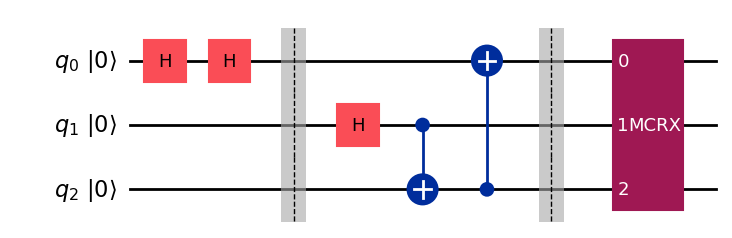

In [39]:
import numpy as np
#GATE
multi_controlled_rx = QuantumCircuit(3, name =r'MCRX' )
multi_controlled_rx.mcrx(theta      = np.pi/3,
            q_controls = [0,1],
            q_target   = 2)
multi_controlled_rx.to_gate()

# CIRCUIT
qc_virtual = QuantumCircuit(3)
# 2 consecutive Hadamard gates
qc_virtual.h(0)
qc_virtual.h(0)
qc_virtual.barrier()
# add a ghz state
qc_virtual.h(1)
qc_virtual.cx(1,2)
qc_virtual.cx(2,0)
qc_virtual.barrier()
# apply the MCRX gate
qc_virtual.append(multi_controlled_rx, [0,1,2])
print('VIRTUAL CIRCUIT')
qc_virtual.draw('mpl',initial_state=True)

#### Generate the pass manager & Transpilation

backend name: ibm_pittsburgh 
num of qubits: 156
PHYSICAL CIRCUIT


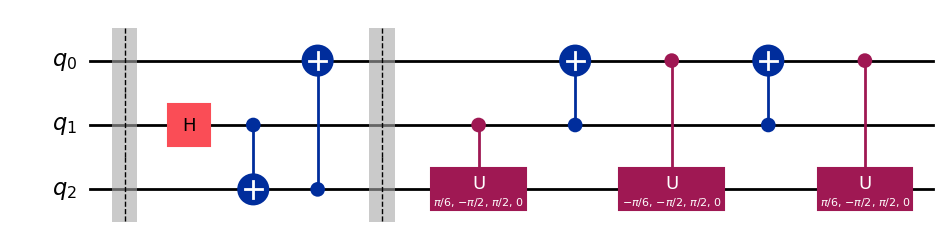

In [40]:
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

print('backend name:',backend.name,'\nnum of qubits:',backend.num_qubits)

pm = generate_preset_pass_manager(backend     = backend,
                                  init_method = 'default',
                                  seed_transpiler = 42)


isa_qc = pm.init.run(qc_virtual)

print('PHYSICAL CIRCUIT')
isa_qc.draw(fold = -1,output= 'mpl')

### Stage 2: Layout (placement)
---


Maps the virtual qubits to the physical qubits (backend qubits).

1. Mimics the virtual circuit in the physical circuit, i.e., maps n-virtual qubits to n-backend-qubits.
2. Expands the virtual circuits operations into backend-native operations.

**Layout methods**
* **default**: When `optimization_level=0`, 1st performs a `VF2Layout` to find a "perfect", if not it performs a `SabreLayout`.

* **dense** (DenseLayout): Searchs for the greatest number of available connection (dense) in the backend qubits.

* **trivial** (TrivialLayout): The $q_{i}^{virtual} \rightarrow q_{i}^{physical}$. Is one-to-one mapping. Hint: you can add a layout in the `QuantumCircuit`.

* **sabre** (SabreLayout): To choose an initial layout, then improves the circuit by doing a `Routing` (explained in the next step), reverse the circuit and apply `Routing` again. It depends of the `optimization_level` to try random initial layouts. For `optimization_level=0` only runs sabre, but for `optimization_level != 0` its tries to find the "perfect" layout, similar to **default**.

**Fez layout**

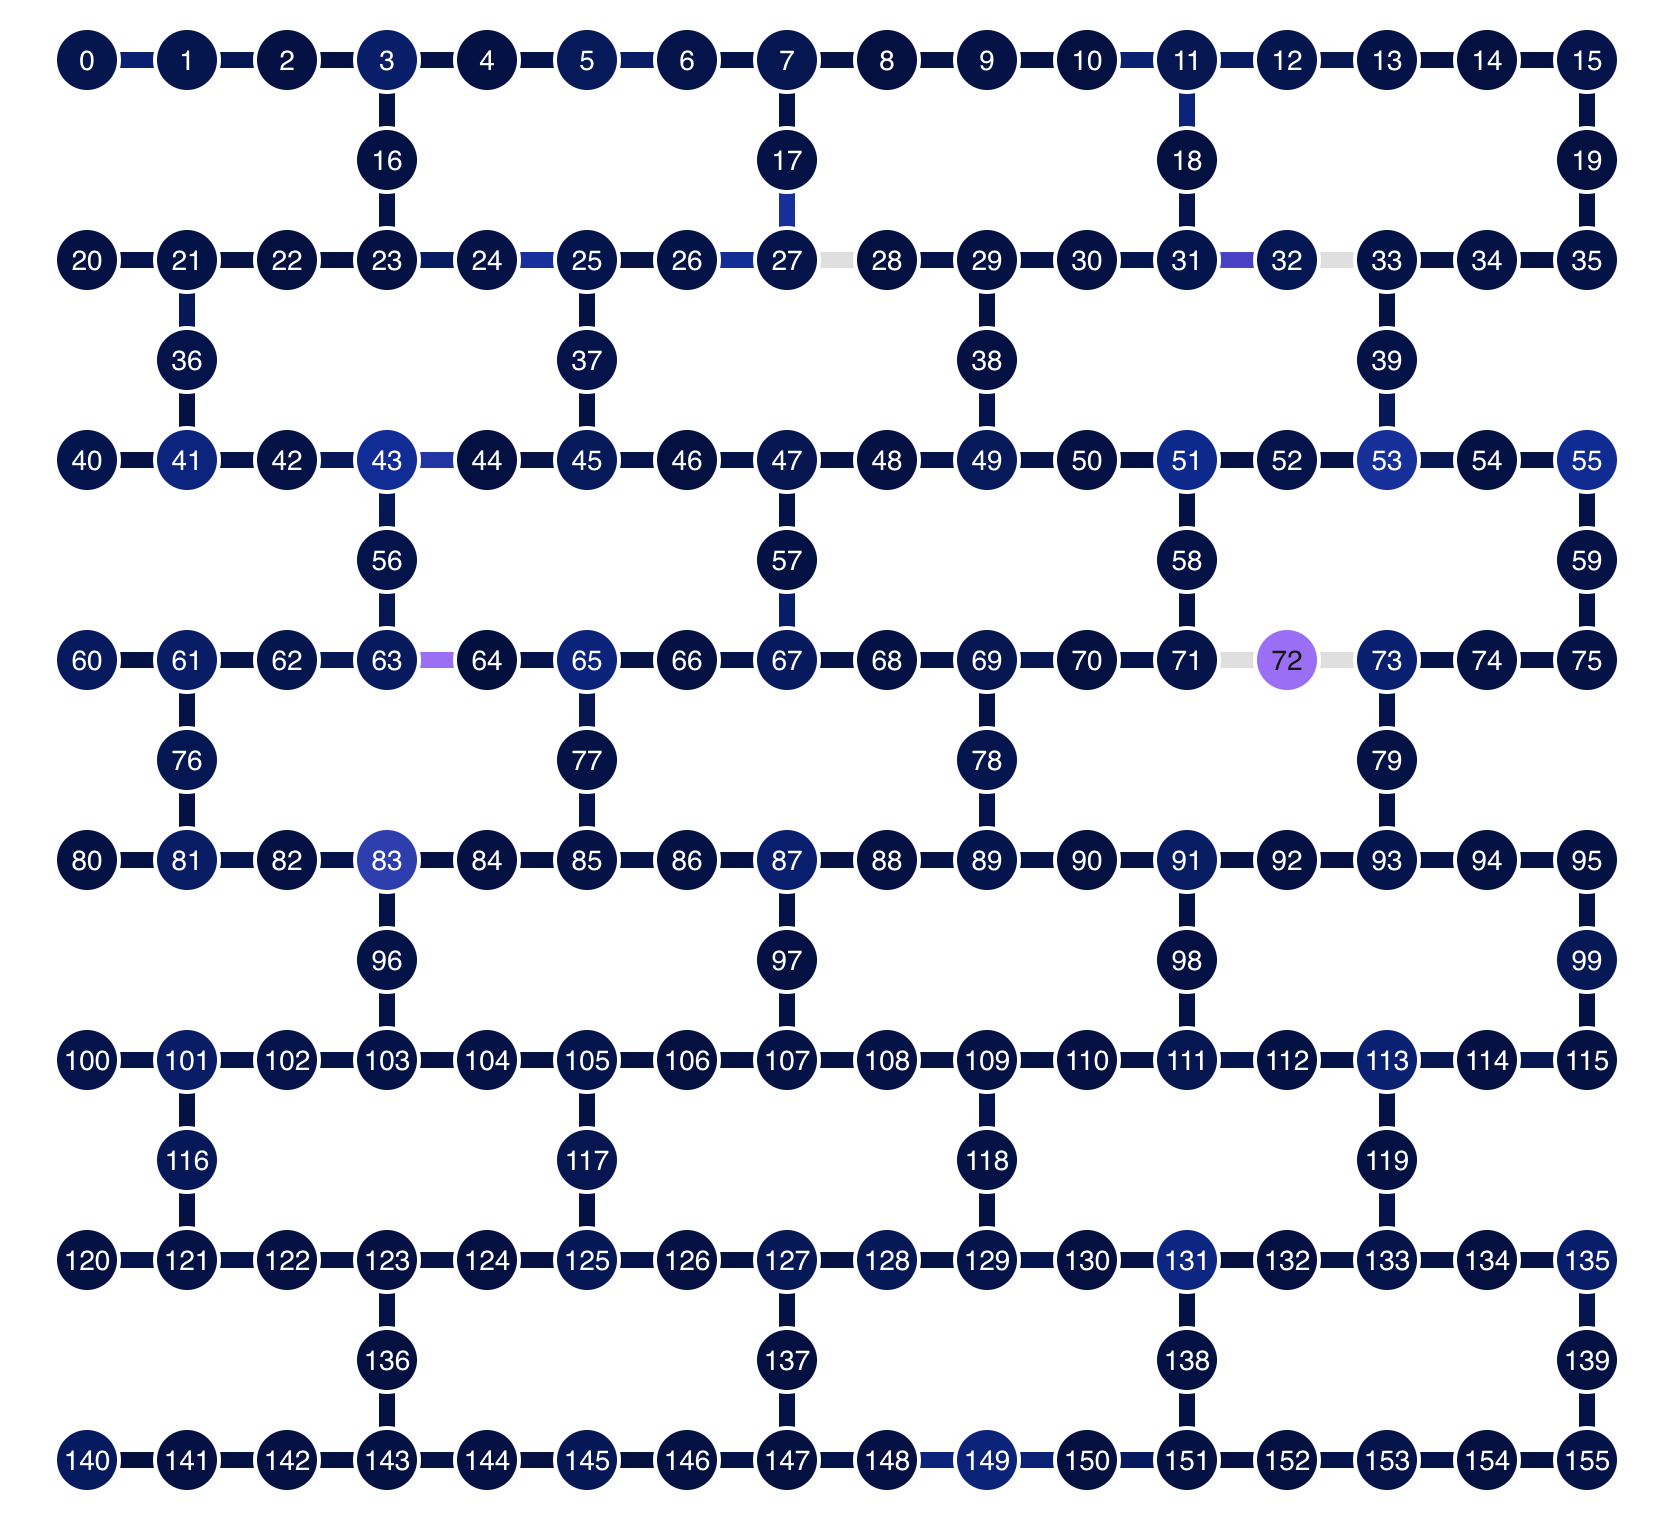

#### Generate the pass manager & Transpilation

Now we run the different layout methods and analyze the different circuits created

Layout Method: default


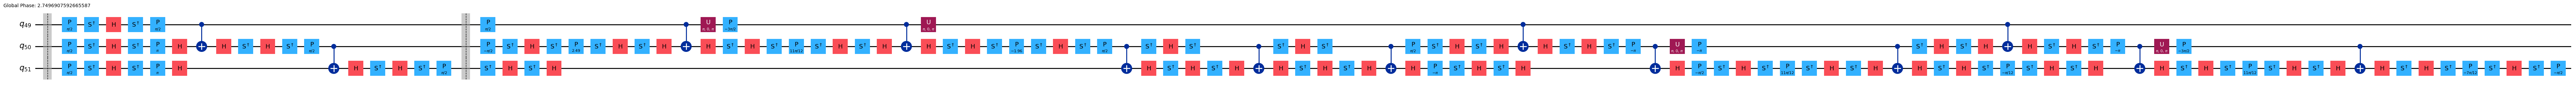

Count Ops: OrderedDict({'sx': 29, 'rz': 27, 'cz': 13, 'x': 4, 'barrier': 2})
Total circuit depth: 51
Number of 2-qubit gates: 13
>> 2-qubit gate depth: 13
>> Score: 16
------------------------------------------------------------------------------------------------------------------------------------------------------
Layout Method: dense


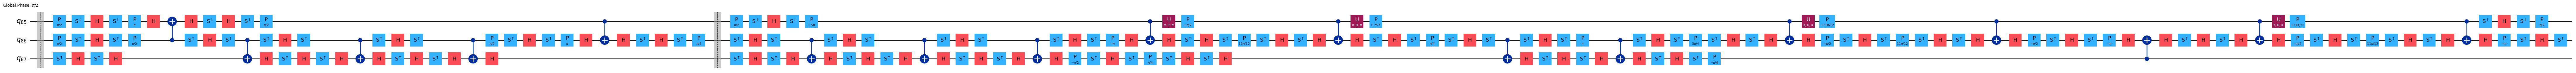

Count Ops: OrderedDict({'sx': 38, 'rz': 30, 'cz': 17, 'x': 4, 'barrier': 2})
Total circuit depth: 58
Number of 2-qubit gates: 17
>> 2-qubit gate depth: 17
>> Score: 21
------------------------------------------------------------------------------------------------------------------------------------------------------
Layout Method: trivial


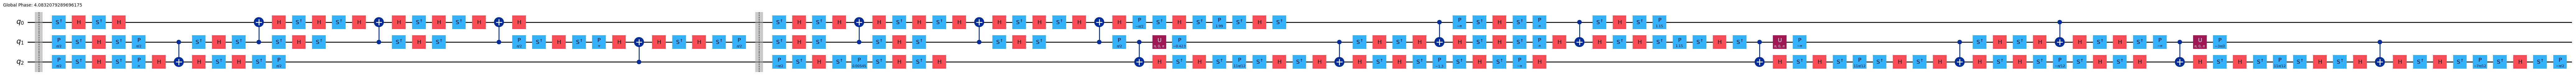

Count Ops: OrderedDict({'sx': 41, 'rz': 30, 'cz': 17, 'x': 3, 'barrier': 2})
Total circuit depth: 55
Number of 2-qubit gates: 17
>> 2-qubit gate depth: 17
>> Score: 20
------------------------------------------------------------------------------------------------------------------------------------------------------
Layout Method: sabre


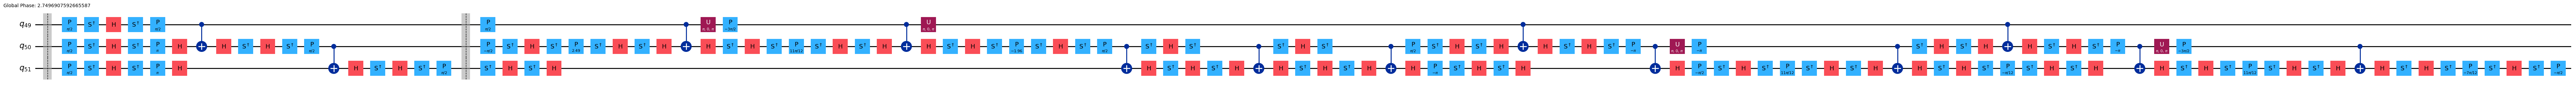

Count Ops: OrderedDict({'sx': 29, 'rz': 27, 'cz': 13, 'x': 4, 'barrier': 2})
Total circuit depth: 51
Number of 2-qubit gates: 13
>> 2-qubit gate depth: 13
>> Score: 16
------------------------------------------------------------------------------------------------------------------------------------------------------


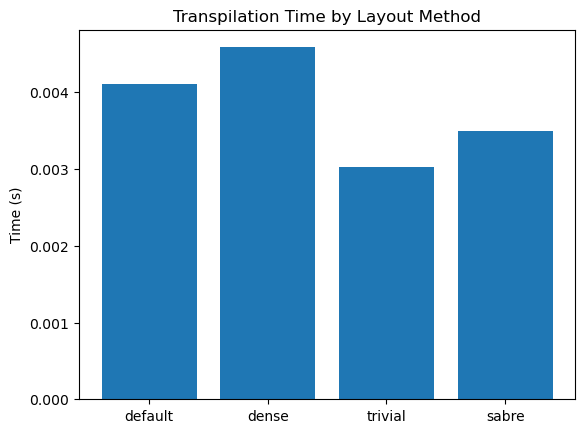

In [41]:
import matplotlib.pyplot as plt

times = []
layout_options = ['default','dense','trivial','sabre']
for ll in layout_options:
   print('\033[1m'+'Layout Method:',ll)
   seed = 42
   pm = generate_preset_pass_manager(
        backend=backend,
        layout_method=ll,
        seed_transpiler=seed
   )
   start      = time.time()
   isa_qc     = pm.run(qc_virtual)
   dt         = time.time()-start
   times.append(dt)
   display(isa_qc.decompose().draw('mpl',fold=-1,idle_wires=False))
   circuit_characteristics(isa_qc)
   print('---'*50)

# Plot transpilation times
plt.bar(layout_options,times)
plt.ylabel('Time (s)')
plt.title('Transpilation Time by Layout Method')
plt.show()

We observe that for this example, the `sabre` (and the `default`) layout method gives us the best transpilation results. Since they minimize the circuit depth and number of gates.

### Stage 3: Routing (Mapping or Swap-mapping) 
---

* ($Graph_{virtual}\rightarrow Graph_{physical}$)

Routing in your circuit ensures hardware compatibility and optimizes execution by inserting necessary swap gates. It also reduces errors by minimizing noise and maximizing fidelity.

Why apply swap gates?
* Because any multi‑qubit operation (such as a CNOT) can only be executed on physically connected qubits.
* If the layout chosen in Stage 2 places interacting qubits far apart, SWAPs move their quantum states until they are adjacent on the hardware’s coupling graph. 

**Routing options**

* **basic**: Searches for qubit swaps following the shortest route, so that the 2-qubit gate becomes executable on the device.
* **sabre**: Uses sabre algorithm to swap the 2-qubit gate operations.
* **stochastic**: Considers operations layer-by-layer, using a stochastic algorithm to find swap networks that implement a suitable permutation to make the layer executable.
* **lookahead**: Explores the nodes in the graph and heuristic techniques to swap gates and make them executable in the physical-graph.


#### Generate the pass manager & Transpilation

We can see that for this example, the circuit output does not change with respect to the routing option selected

layout method: basic


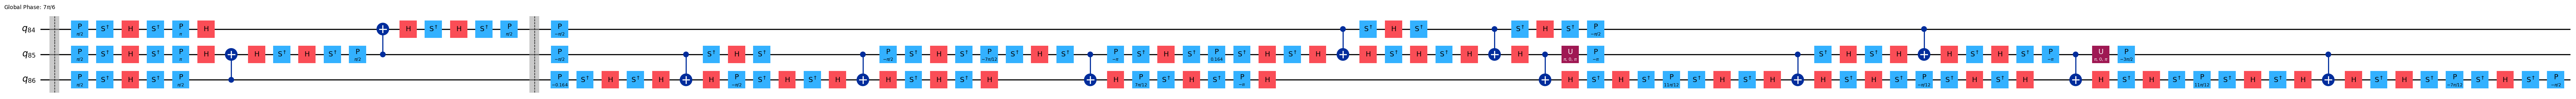

Count Ops: OrderedDict({'rz': 27, 'sx': 27, 'cz': 12, 'barrier': 2, 'x': 2})
Total circuit depth: 45
Number of 2-qubit gates: 12
>> 2-qubit gate depth: 12
>> Score: 15
------------------------------------------------------------------------------------------------------------------------------------------------------
layout method: sabre


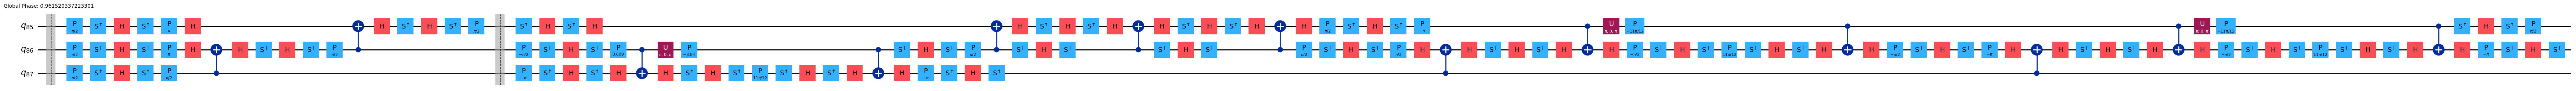

Count Ops: OrderedDict({'rz': 29, 'sx': 27, 'cz': 13, 'x': 3, 'barrier': 2})
Total circuit depth: 48
Number of 2-qubit gates: 13
>> 2-qubit gate depth: 13
>> Score: 16
------------------------------------------------------------------------------------------------------------------------------------------------------
layout method: lookahead


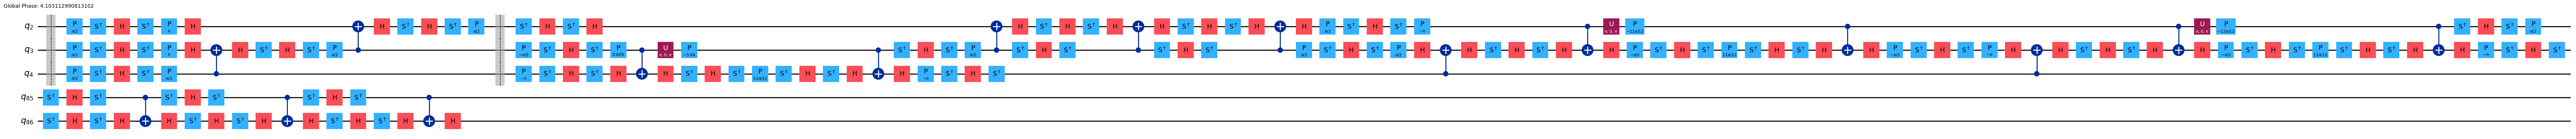

Count Ops: OrderedDict({'sx': 33, 'rz': 29, 'cz': 16, 'x': 3, 'barrier': 2})
Total circuit depth: 48
Number of 2-qubit gates: 16
>> 2-qubit gate depth: 13
>> Score: 16
------------------------------------------------------------------------------------------------------------------------------------------------------


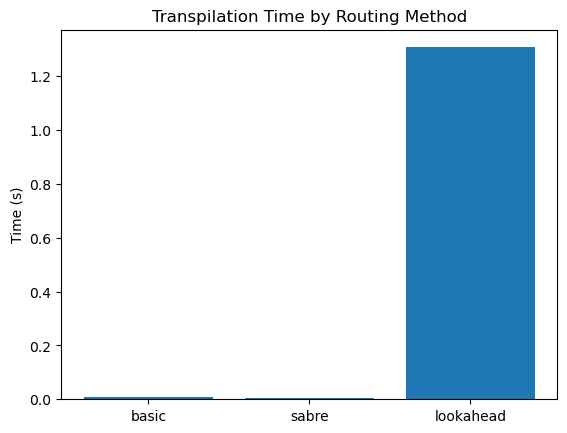

In [42]:

routing_options = ['basic','sabre','lookahead',]
times = []
for oo in routing_options:
    print('\033[1m'+'layout method:',oo)

    seed = 42
    pm = generate_preset_pass_manager(
        backend=backend,
        routing_method=oo,
        seed_transpiler=seed
    )

    start      = time.time()
    isa_qc     = pm.run(qc_virtual)
    dt         = time.time()-start
    times.append(dt)
    display(isa_qc.decompose().draw('mpl',fold=-1,idle_wires=False))
    circuit_characteristics(isa_qc)
    print('---'*50)

# Plot transpilation times
plt.bar(routing_options,times)
plt.ylabel('Time (s)')
plt.title('Transpilation Time by Routing Method')
plt.show()

Here the `sabre` routing method presents the smallest circuit depth and number of gates, however the `basic` routing method has one less two-qubit gate, making their performance comparable.

### Stage 4: Translation
---

Translates the gates in the virtual circuit to ones native to the backend.

**Translation methods**

* **translator**: Symbolic translation of gates to the target basis using known equivalences.
* **synthesis**:  Collect each run of one- and two-qubit gates into a matrix representation, and resynthesize from there.

#### Generate the pass manager & Transpilation

Let's analyze the two different translation methods

Translation Method: translator


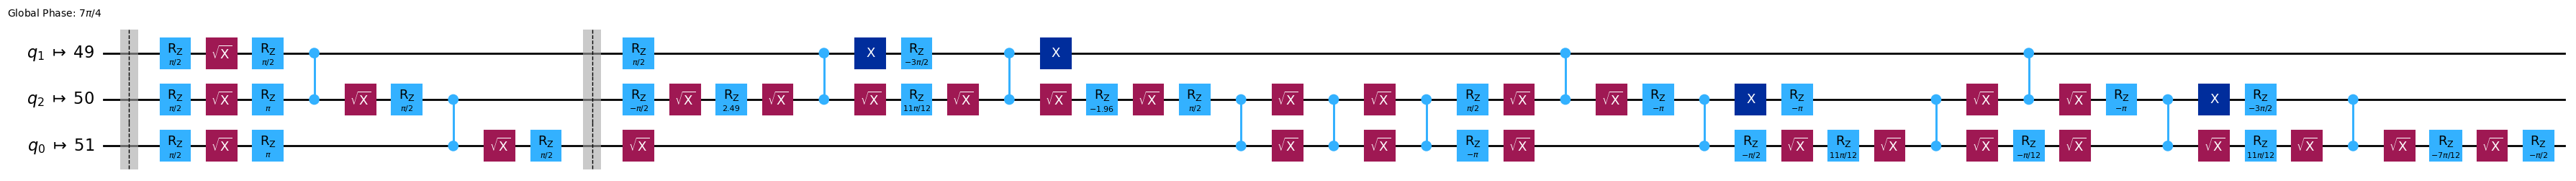

Count Ops: OrderedDict({'sx': 29, 'rz': 27, 'cz': 13, 'x': 4, 'barrier': 2})
Total circuit depth: 51
Number of 2-qubit gates: 13
>> 2-qubit gate depth: 13
>> Score: 16
------------------------------------------------------------------------------------------------------------------------------------------------------
Translation Method: synthesis


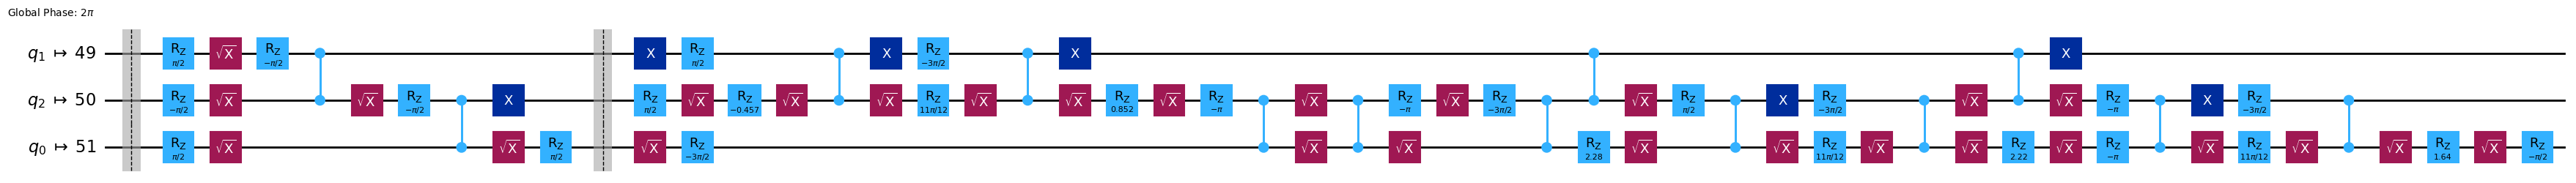

Count Ops: OrderedDict({'sx': 28, 'rz': 27, 'cz': 13, 'x': 7, 'barrier': 2})
Total circuit depth: 50
Number of 2-qubit gates: 13
>> 2-qubit gate depth: 13
>> Score: 16
------------------------------------------------------------------------------------------------------------------------------------------------------


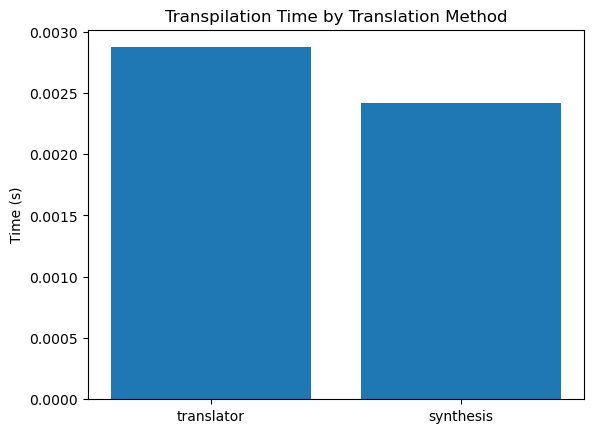

In [43]:
translation_methods = ['translator', 'synthesis']
times = []

for method in translation_methods:
    print('\033[1m' + f'Translation Method: {method}')
    
    seed = 42
    pm = generate_preset_pass_manager(
        backend=backend,
        layout_method='sabre',
        routing_method='sabre',
        translation_method=method,
        seed_transpiler=seed
    )
    
    start = time.time()
    isa_qc = pm.run(qc_virtual)
    dt = time.time() - start
    times.append(dt)
    
    display(isa_qc.draw('mpl', fold=-1))
    circuit_characteristics(isa_qc)
    print('---' * 50)

# Plot transpilation times
plt.bar(translation_methods, times)
plt.ylabel('Time (s)')
plt.title('Transpilation Time by Translation Method')
plt.show()

The circuit with smaller circuit depth and number of gates is the one transpiled using the `translator` Translation method.

### Stage 5: Optimization
---

The optimization stage in quantum circuit transpilation focuses on making low-level improvements, considering the specific characteristics of the hardware. This stage optimizes the circuits to work more efficiently on the quantum device.

Key points:

* Low-level optimization: Detailed adjustments are made to the circuit to enhance its performance on the specific hardware.
* ISA-compatible circuits: The input and output of this stage are circuits that are already compatible with the hardware's instruction set architecture (ISA).
* Iteration and adjustments: This stage often includes an optimization loop that can make multiple adjustments until the best possible result is achieved.

#### Generate the pass manager & Transpilation
We can now study how the number of gates and the circuit depth are optimized as we increase the optimization level from 0 to 3


Optimization Level: 0


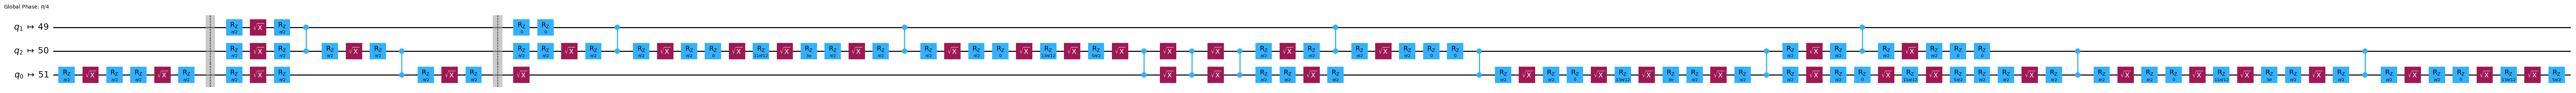

Count Ops: OrderedDict({'rz': 73, 'sx': 41, 'cz': 13, 'barrier': 2})
Total circuit depth: 103
Number of 2-qubit gates: 13
>> 2-qubit gate depth: 13
>> Score: 22
------------------------------------------------------------------------------------------------------------------------------------------------------
Optimization Level: 1


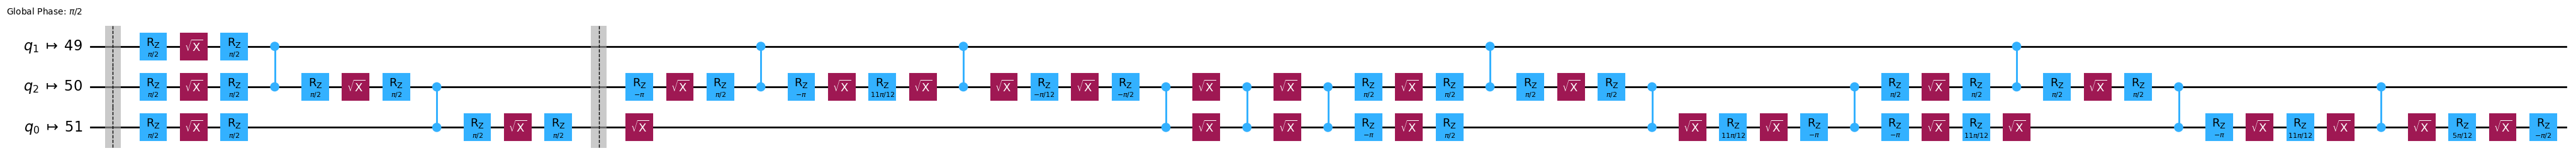

Count Ops: OrderedDict({'rz': 34, 'sx': 28, 'cz': 13, 'barrier': 2})
Total circuit depth: 59
Number of 2-qubit gates: 13
>> 2-qubit gate depth: 13
>> Score: 17
------------------------------------------------------------------------------------------------------------------------------------------------------
Optimization Level: 2


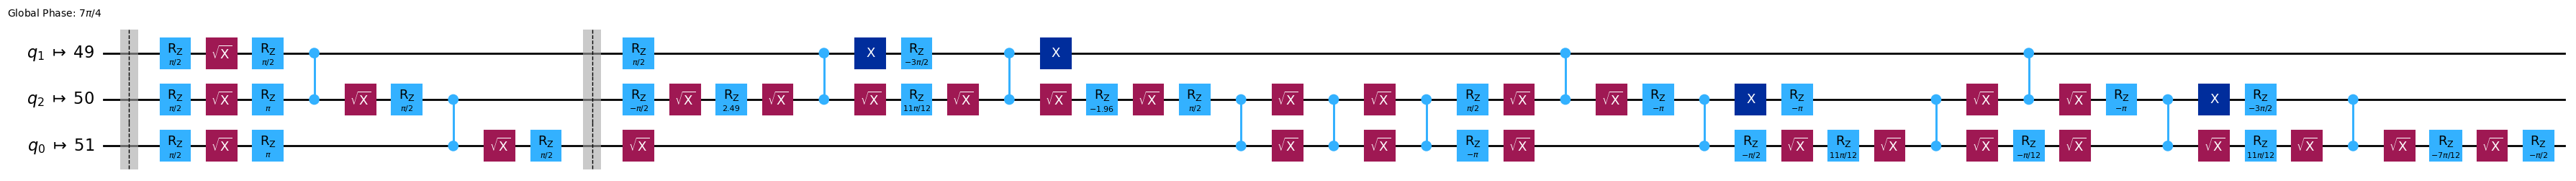

Count Ops: OrderedDict({'sx': 29, 'rz': 27, 'cz': 13, 'x': 4, 'barrier': 2})
Total circuit depth: 51
Number of 2-qubit gates: 13
>> 2-qubit gate depth: 13
>> Score: 16
------------------------------------------------------------------------------------------------------------------------------------------------------
Optimization Level: 3


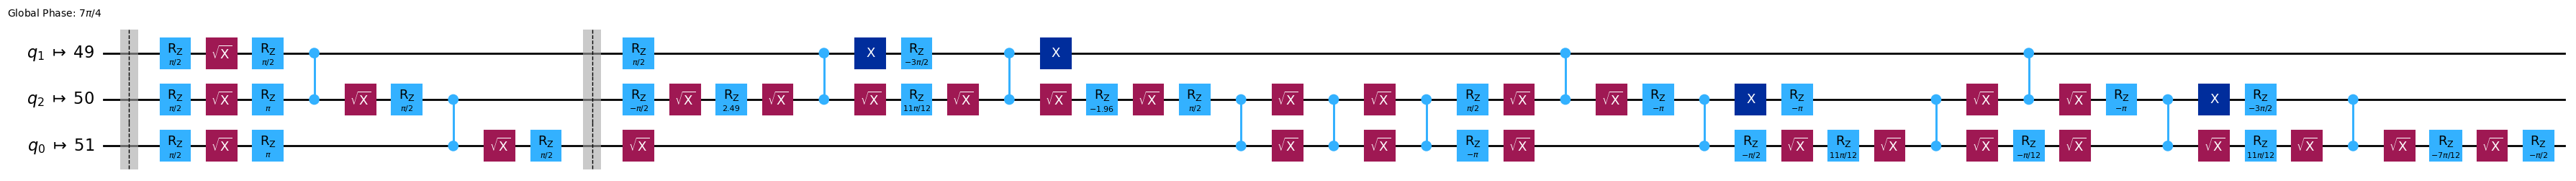

Count Ops: OrderedDict({'sx': 29, 'rz': 27, 'cz': 13, 'x': 4, 'barrier': 2})
Total circuit depth: 51
Number of 2-qubit gates: 13
>> 2-qubit gate depth: 13
>> Score: 16
------------------------------------------------------------------------------------------------------------------------------------------------------


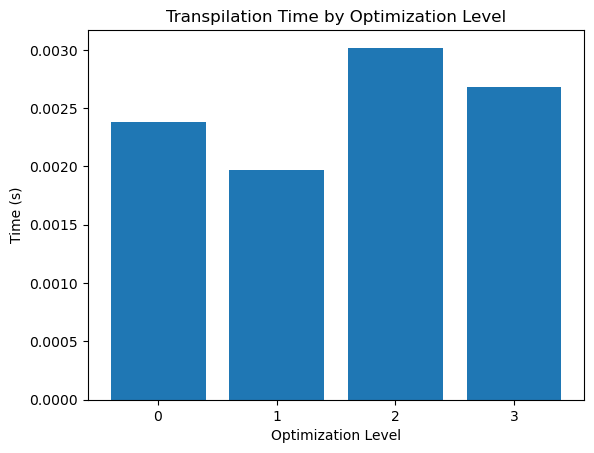

In [44]:

optimization_levels = [0, 1, 2, 3]
times = []

for level in optimization_levels:
    print('\033[1m' + f'Optimization Level: {level}')
    
    seed = 42
    pm = generate_preset_pass_manager(
        optimization_level=level,
        backend=backend,
        layout_method='sabre',
        routing_method='sabre',
        translation_method='translator',
        seed_transpiler=seed
    )
    
    start = time.time()
    isa_qc = pm.run(qc_virtual)
    dt = time.time() - start
    times.append(dt)
    
    display(isa_qc.draw('mpl', fold=-1))
    circuit_characteristics(isa_qc)
    print('---' * 50)

# Plot transpilation times
plt.bar([str(lvl) for lvl in optimization_levels], times)
plt.xlabel('Optimization Level')
plt.ylabel('Time (s)')
plt.title('Transpilation Time by Optimization Level')
plt.show()


We observe that `optimization_level` of 2 and 3 yield equally good results.

### Stage 6: Scheduling
---

The Scheduling stage in quantum circuit transpilation is responsible for inserting explicit Delay instructions to account for idle periods of qubits. This stage ensures that the timing of operations is aligned with the hardware's constraints.

Key points:

* Explicit Delays: Adds Delay instructions to make idle times explicit.
* Timing Constraints: Ensures operations meet the hardware's timing requirements.
* Dynamical Decoupling: May include techniques like dynamical decoupling to reduce errors.

#### Generate the pass manager & Transpilation
Let's take a look at the two scheduling methods `alap` and `asap`

Scheduling Method: alap


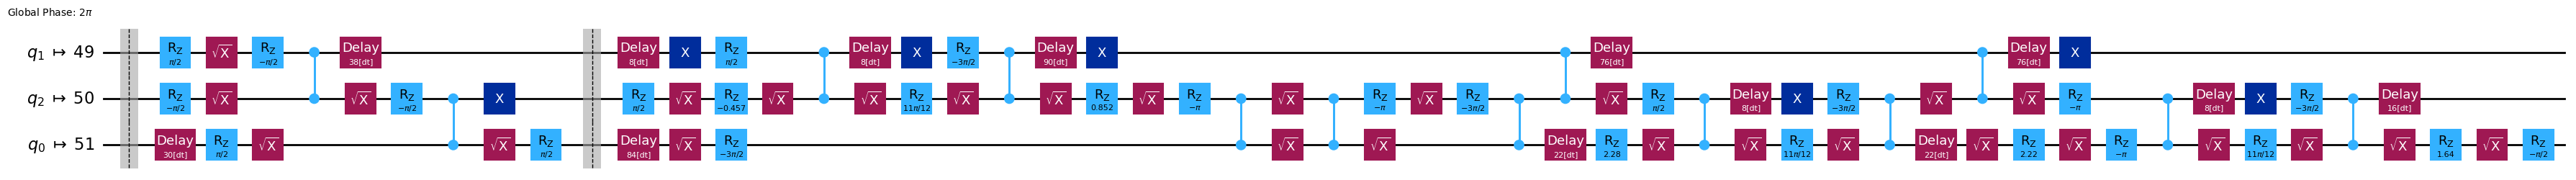

Count Ops: OrderedDict({'delay': 166, 'sx': 28, 'rz': 27, 'cz': 13, 'x': 7, 'barrier': 2})
Total circuit depth: 51
Number of 2-qubit gates: 13
>> 2-qubit gate depth: 13
>> Score: 17
------------------------------------------------------------------------------------------------------------------------------------------------------
Scheduling Method: asap


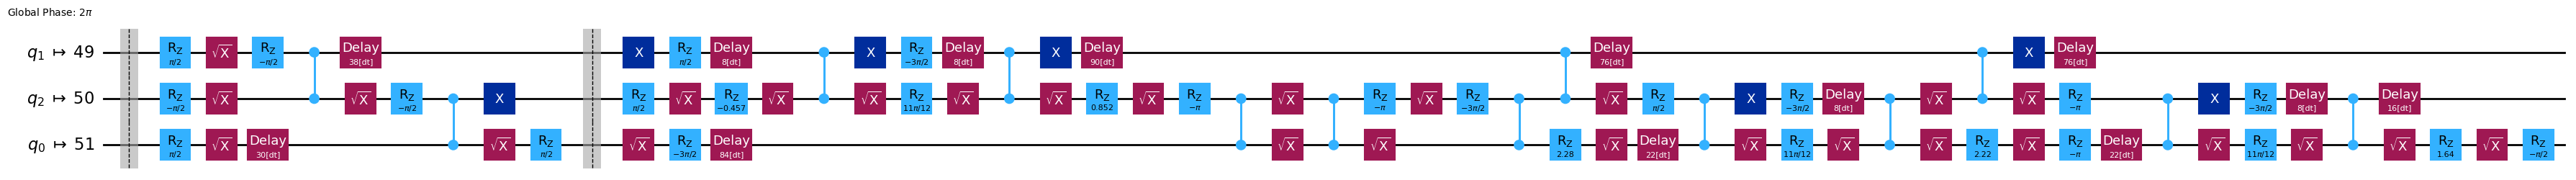

Count Ops: OrderedDict({'delay': 166, 'sx': 28, 'rz': 27, 'cz': 13, 'x': 7, 'barrier': 2})
Total circuit depth: 51
Number of 2-qubit gates: 13
>> 2-qubit gate depth: 13
>> Score: 17
------------------------------------------------------------------------------------------------------------------------------------------------------


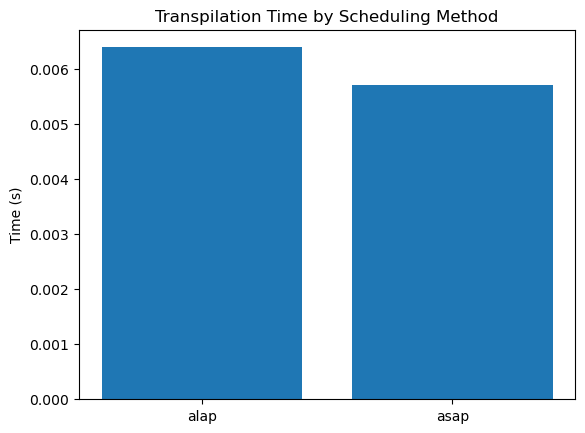

In [45]:

scheduling_methods = ['alap', 'asap']
times = []

for method in scheduling_methods:
    print('\033[1m' + f'Scheduling Method: {method}')
    
    seed = 42
    pm = generate_preset_pass_manager(
        optimization_level=3,
        backend=backend,
        layout_method='sabre',
        routing_method='sabre',
        translation_method='synthesis',
        scheduling_method=method,
        seed_transpiler=seed
    )
    
    start = time.time()
    isa_qc = pm.run(qc_virtual)
    dt = time.time() - start
    times.append(dt)
    
    display(isa_qc.draw('mpl', fold=-1))
    circuit_characteristics(isa_qc)
    print('---' * 50)

# Plot transpilation times
plt.bar(scheduling_methods, times)
plt.ylabel('Time (s)')
plt.title('Transpilation Time by Scheduling Method')
plt.show()


The difference between these two methods cannot be seen in the transpiled circuit, since `ASAP` schedules gates as early as possible to minimize total runtime, whereas
`ALAP` schedules them as late as possible to reduce qubit idle time before measurement, hence decreasing the chance of decoherence errors. To learn more about this, you can check the [Transpiler documentation](https://quantum.cloud.ibm.com/docs/en/api/qiskit/transpiler#transpiler-scheduling-description).

## 4. Outlook and general strategies

In this hands-on we have seen in detail the different steps during the transpilation process. Focusing on how different methods at each step can help reduce the overall complexity of a quantum circuit. However, in the end what we are aiming for is a general strategy to optimize the transpilation in a way that best adapts our circuit to the hardware we are executing it on. To do so, you can check out [this material](https://github.com/qiskit-community/qgss-2025/blob/main/lab-2/Lab2.ipynb) and take a look at the table below.

### General Strategies Cheat Sheet

| **Strategy**                             | **When to Use This Strategy?**                                                        | **Why?**                                                                                                                                        | **How Much Improvement?**                                                                                       | **Implementation**                                                                                                                        |
|------------------------------------------|--------------------------------------------------------------------------------------|------------------------------------------------------------------------------------------------------------------------------------------------|-----------------------------------------------------------------------------------------------------------------|-----------------------------------------------------------------------------------------------------------------------------------------|
| **Try transpiling multiple times**       | Always (May not be needed in most cases now. Use `SabreLayout` and increase `trial_count` argument instead.) | Many transpilation passes are stochastic. Running the transpiler multiple times may result in better outcomes.                                                     | Transpile multiple times in a loop and keep the best result.                                                   | Utilize a loop or a genetic algorithm to mutate and evolve a better transpiler workflow.                                                                       |
| **Experiment with different synthesis methods** | When working with high-level objects that have multiple synthesis options (e.g., Cliffords, LinearFunctions, MCX gates, sequences of Pauli rotations) | Different synthesis methods can produce circuits with varying depths and gate counts without changing the operator. | Can optimize circuit depth and size without modifying functionality. | Specify different synthesis methods using `hls_config` in Qiskit. |
| **Dropping the final Clifford (operator backpropagation)** | When measuring an observable                                                  | Can potentially reduce the circuit depth with minimal overhead cost. | May help optimize depth without much extra complexity. | Implement operator backpropagation by rearranging gate sequences.                                                                                                                                         |
| **Apply dynamical decoupling**              | For devices with high crosstalk errors (e.g., Heron); may not be effective in all devices            | Dynamical decoupling can suppress crosstalk errors between qubits.                                                                                               | Potential improvements for specific hardware architectures. | Use Qiskit Runtime’s dynamical decoupling capabilities or create a custom decoupling pass.                                                                                                                              |
| **Numerical approximate methods**        | Large networks of CNOTs or Clifford gates                                             | Useful when dealing with many gates on relatively few qubits.                                                                                           | Can simplify circuits with large gate counts. | Explore numerical approximation methods for gate simplification.                                                                                                                                         |
| **Use SabrePreLayout**                   |  When the quality of the circuit (both size and depth) is more important than the transpilation runtime        | Helps reduce overall circuit depth by optimizing layout before routing.                                                                                               | Useful when depth is a more critical factor than size. | Useful for niche set of applications                                       |
| **Leverage Pauli synthesis tools**       | For circuits with large sequences of multi-qubit Pauli rotations or Trotter decomposition problems. | Optimizing Pauli rotations can significantly reduce circuit depth, especially in hardware with limited connectivity. | May result in substantial depth reduction in circuits with many Pauli rotations. | Use Pauli synthesis tools in Qiskit or Rustiq for Trotter circuits.                                                                                             |
| **Use approximation degree** |	For deep circuits where a trade-off between accuracy and circuit depth is acceptable (Approximates the operator)	| Trading off accuracy with fewer gates/lower depth may improve results. |	Can significantly reduce depth by allowing approximate gate synthesis.	| Use the approximation_degree parameter in Qiskit's transpiler. |








# Bonus: Qiskit Addon Operator Backpropagation 

*Estimated QPU usage: 2 minutes (tested on IBM Kingston)*


The Operator Back Propagation (OBP) is described in detail [here](https://arxiv.org/abs/2502.01897). When using the **Estimator** primitive, the output of a quantum workload is the estimation of one or more expectation values $\langle O \rangle$ with respect to some state prepared using a QPU. This section summarizes the procedure.

First, write the expectation value of an observable $O$ in terms of an initial state $\lvert \psi \rangle$ and a quantum circuit $U$:
$$
\langle O \rangle_{U \lvert \psi \rangle} \;=\; \langle \psi \rvert\, U^\dagger\, O\, U \,\lvert \psi \rangle.
$$

To distribute this computation across classical and quantum resources, split the circuit $U$ into two subcircuits, $U_C$ and $U_Q$. Classically simulate the circuit $U_C$, then execute the circuit $U_Q$ on quantum hardware, and use the results of the classical simulation to reconstruct the measurement of the observable $O$:
$$
U \;=\; U_Q\, U_C.
$$


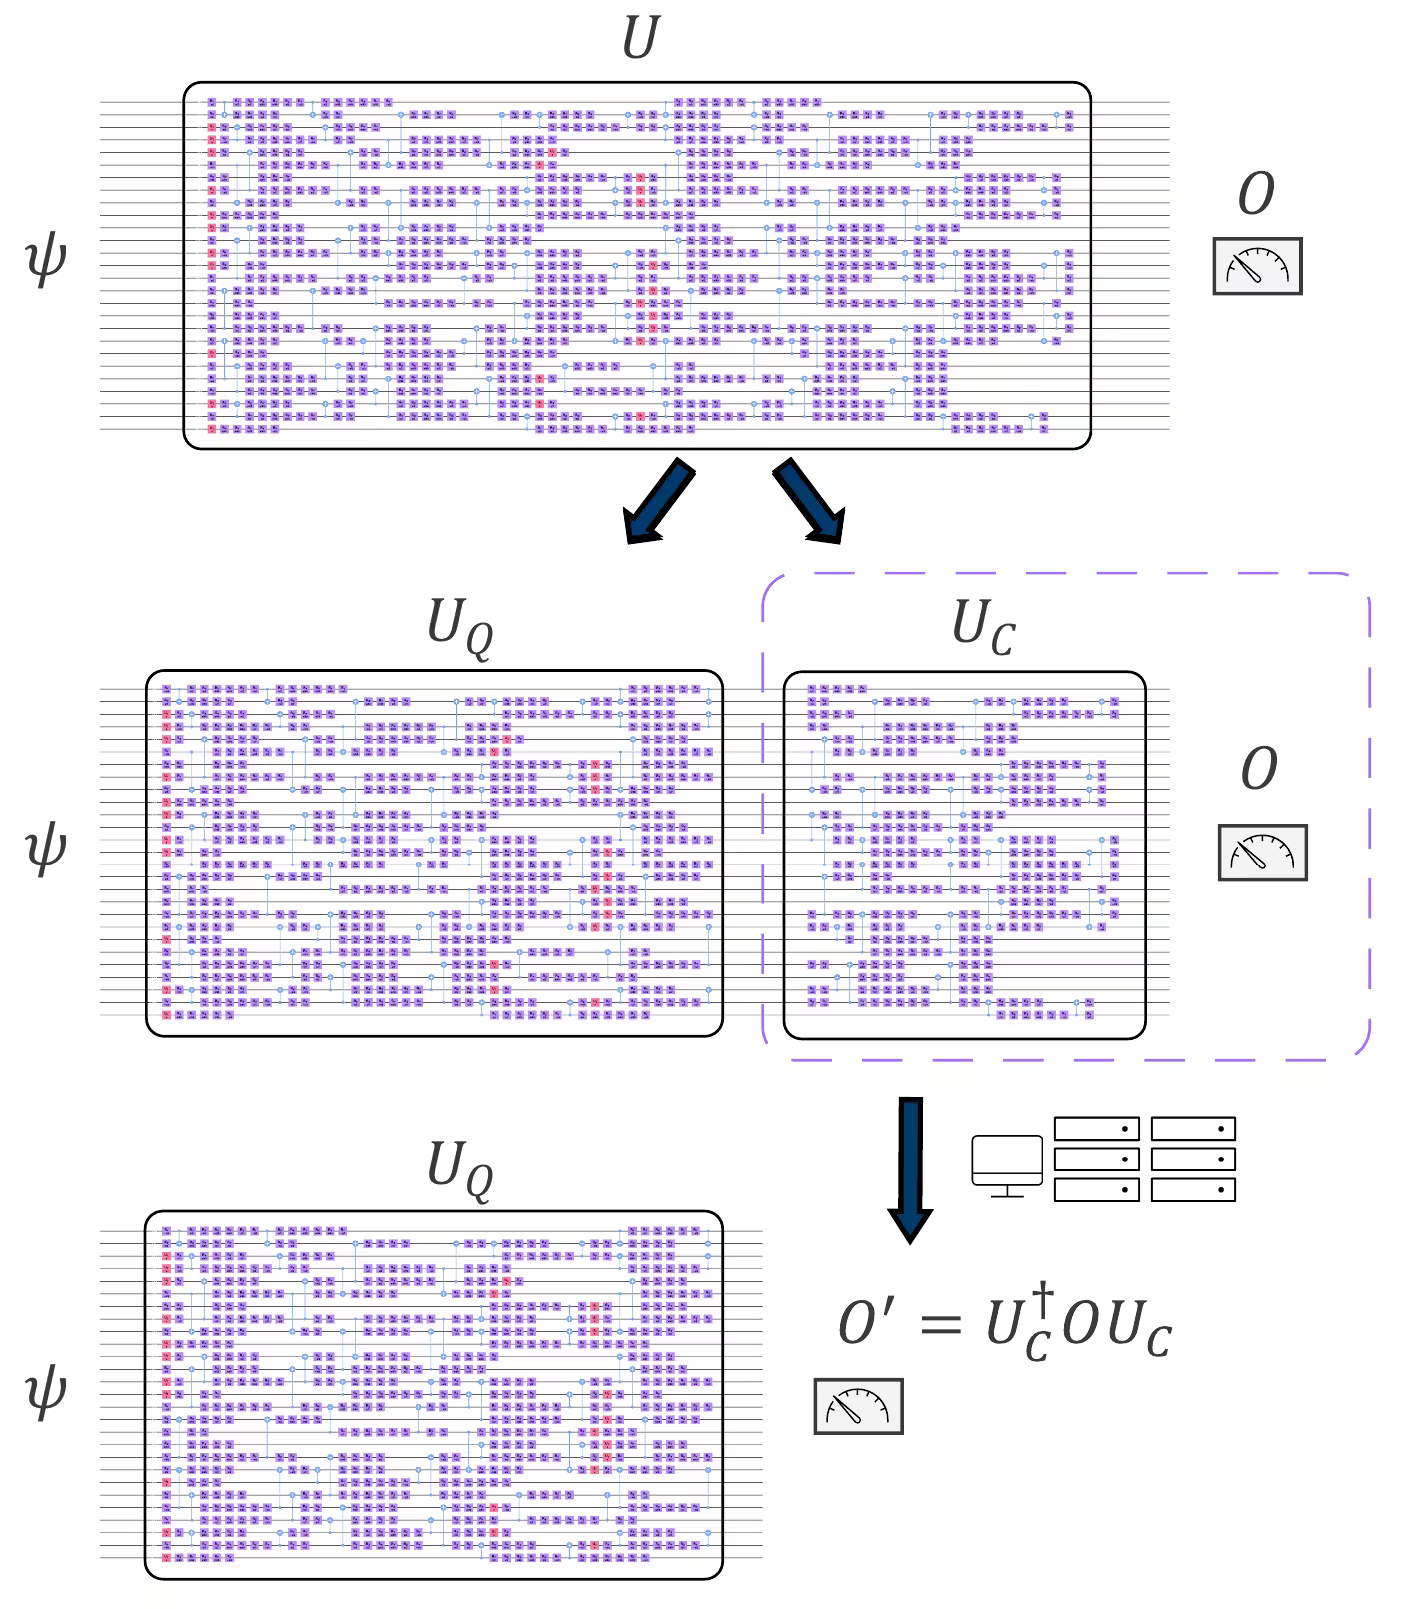


The subcircuit $U_C$ should be selected to be classically simulable and will compute the expectation value

$$
\langle O' \rangle \equiv U_C^\dagger O U_C,
$$

which is the version of the initial operator $O$ evolved through the circuit $U_C$. Once $O'$ has been determined, the quantum workload is prepared wherein the state $\lvert \psi \rangle$ is initiated, has the circuit $U_Q$ applied to it, and then measures the expectation value $O'$. You can show that this is equivalent to measuring $\langle O \rangle$ by writing:

$$
\langle \psi \lvert U_Q^\dagger O' U_Q \rvert \psi \rangle
= \langle \psi \lvert U_Q^\dagger U_C^\dagger O U_C U_Q \rvert \psi \rangle
= \langle \psi \lvert U^\dagger O U \rvert \psi \rangle
= \langle O \rangle_{U \lvert \psi \rangle}.
$$

Lastly, in order to measure the expectation value $\langle O' \rangle$, we must require it to be decomposable into a sum of Pauli strings:

$$
O' = \sum_P c_P P,
$$

where $c_P$ are real coefficients of the decomposition and $P$ is some Pauli string composed of $I, X, Y,$ and $Z$ operators. This ensures that you can reconstruct the expectation value of $O$ by

$$
\langle \psi \lvert U_Q^\dagger O' U_Q \rvert \psi \rangle
= \sum_P c_P \langle \psi \lvert U_Q^\dagger P U_Q \rvert \psi \rangle.
$$


In [46]:
%pip install qiskit-addon-utils
%pip install qiskit-addon-obp

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [ ]:
from qiskit.primitives import StatevectorEstimator
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit.quantum_info import SparsePauliOp
from qiskit_ibm_runtime import QiskitRuntimeService

from qiskit_addon_utils.slicing import slice_by_gate_types, combine_slices
from qiskit_addon_obp.utils.simplify import OperatorBudget
from qiskit_addon_obp import backpropagate
from qiskit_addon_obp.utils.truncating import setup_budget

from qiskit_ibm_runtime import EstimatorV2, EstimatorOptions

from qiskit.circuit.library import efficient_su2
from qiskit.circuit.library import unitary_overlap

import numpy as np
import matplotlib.pyplot as plt

### Step 1: Map classical inputs to a quantum problem

For simplicity this notebook uses the [`efficient_su2`](https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.circuit.library.efficient_su2) circuit included in Qiskit's circuit library.

`efficient_su2` is a parameterized quantum circuit designed to be efficiently executable on quantum hardware with limited qubit connectivity, while still being expressive enough to solve problems in application domains like optimization and chemistry. It's built by alternating layers of parameterized single-qubit gates with a layer containing a fixed pattern of two-qubit gates, for a chosen number of repetitions. The pattern of two-qubit gates can be specified by the user. Here you can use the built-in `pairwise` pattern because it minimizes the circuit depth by packing the two-qubit gates as densely as possible. 

After constructing this circuit, we apply its mirror image (i.e. its inverse), resulting in an overall circuit that implements the identity. Hence, the expectation value of any observable which is made up of only Pauli Z's and identities (and has coefficients that sum to 1) will, in an ideal noiseless case be equal to 1. We will consider an observable of this form in the Step 2.

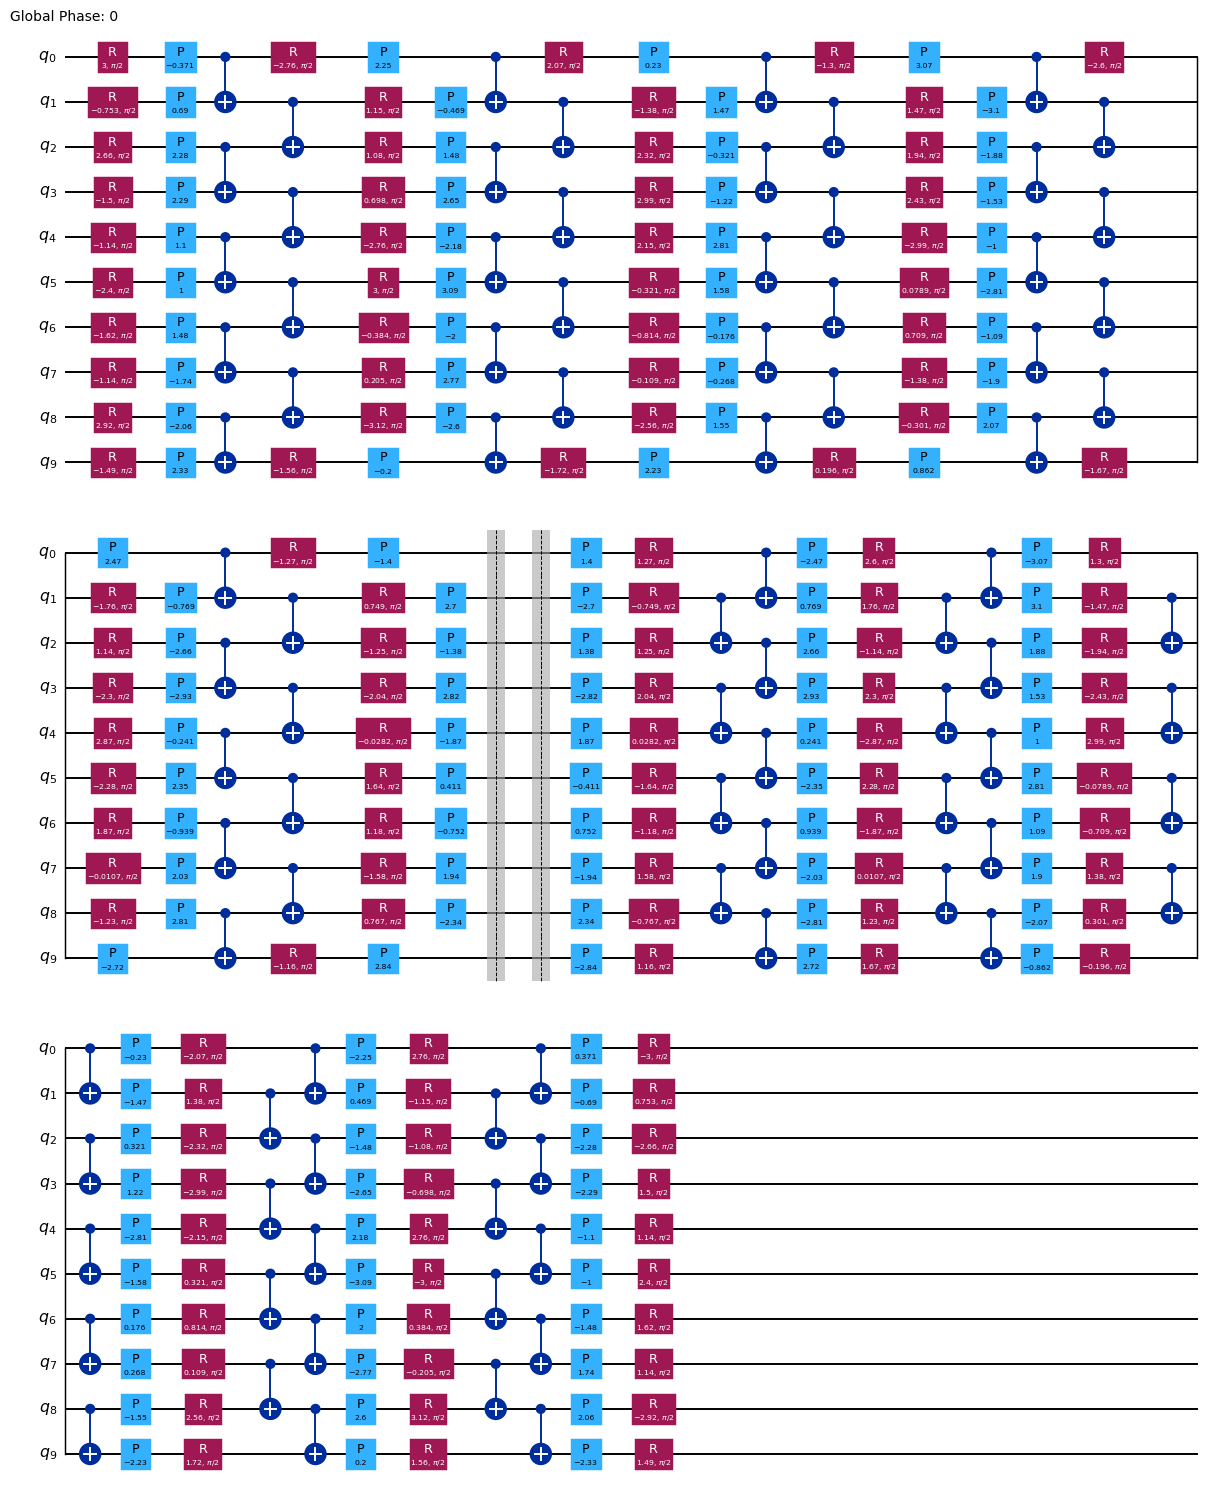

In [48]:
num_qubits = 10
circuit = efficient_su2(num_qubits=num_qubits, reps=5, entanglement='pairwise')

# Generate random parameters
rng = np.random.default_rng(1234)
params = rng.uniform(-np.pi, np.pi, size=circuit.num_parameters)

# Assign the parameters to the circuit
assigned_circuit = circuit.assign_parameters(params)

# Add a barrier to prevent circuit optimization of mirrored operators
assigned_circuit.barrier()

# Construct mirror circuit
mirror_circuit = unitary_overlap(assigned_circuit, assigned_circuit)

mirror_circuit.decompose().draw("mpl", scale=0.7)


### Step 2: Optimize problem for quantum hardware execution

#### Create circuit slices to backpropagate

Remember, the `backpropagate` function will backpropagate entire circuit slices at a time, so the choice of how to slice can have an impact on how well backpropagation performs for a given problem. Here, we will group gates of the same type into slices using the [slice\_by\_gate\_types](https://quantum.cloud.ibm.com/docs/api/qiskit-addon-utils/slicing#slice_by_gate_types) function.

For a more detailed discussion on circuit slicing, check out this [how-to guide](https://qiskit.github.io/qiskit-addon-utils/how_tos/create_circuit_slices.html) of the [qiskit-addon-utils](https://github.com/Qiskit/qiskit-addon-utils) package.


In [49]:
slices = slice_by_gate_types(mirror_circuit)
print(f"Separated the circuit into {len(slices)} slices.")

Separated the circuit into 46 slices.


#### Constrain how large the operator may grow during backpropagation

During backpropagation, the number of terms in the operator will generally approach $4^N$ quickly, where $N$ is the number of qubits. When two terms in the operator do not commute qubit-wise, we need separate circuits to obtain the expectation values corresponding to them. For example, if we have a 2-qubit observable $O = 0.1 XX + 0.3 IZ - 0.5 IX$, then since $[XX,IX] = 0$, measurement in a single basis is sufficient to calculate the expectation values for these two terms. However, $IZ$ anti-commutes with the other two terms. So we need a separate basis measurement to calculate the expectation value of $IZ$. In other words, we need two, instead of one, circuit to calculate $\langle O \rangle$. As the number of terms in the operator increase, there is a possibility that the required number of circuit executions also increase.

The size of the operator can be bounded by specifying the `operator_budget` kwarg of the `backpropagate` function, which accepts an [OperatorBudget](https://quantum.cloud.ibm.com/docs/api/qiskit-addon-obp/utils-simplify#operatorbudget) instance.

To control the amount of extra resources (time) allocated, we restrict the maximum number of qubit-wise commuting Pauli groups that the backpropagated observable is allowed to have. Here we specify that backpropagation should stop when the number of qubit-wise commuting Pauli groups in the operator grows past 8.

In [50]:
op_budget = OperatorBudget(max_qwc_groups=8)

#### Backpropagate slices from the circuit

First we specify the observable to be $M_Z = \frac{1}{N} \sum_{i=1}^N \langle Z_i \rangle$, where $N$ is the number of qubits. For our considered circuit, the expectation value of this observable is equal to 1.

We will backpropagate slices from the time-evolution circuit until the terms in the observable can no longer be combined into eight or fewer qubit-wise commuting Pauli groups.


In [51]:
observable = SparsePauliOp.from_sparse_list(
    [("Z", [i], 1 / num_qubits) for i in range(num_qubits)],
    num_qubits=num_qubits,)
print(observable)

SparsePauliOp(['IIIIIIIIIZ', 'IIIIIIIIZI', 'IIIIIIIZII', 'IIIIIIZIII', 'IIIIIZIIII', 'IIIIZIIIII', 'IIIZIIIIII', 'IIZIIIIIII', 'IZIIIIIIII', 'ZIIIIIIIII'],
              coeffs=[0.1+0.j, 0.1+0.j, 0.1+0.j, 0.1+0.j, 0.1+0.j, 0.1+0.j, 0.1+0.j, 0.1+0.j,
 0.1+0.j, 0.1+0.j])


Below you will see that we backpropagated four slices, and the terms were combined into six and not eight groups. This implies that backpropagating one more slice would cause the number of Pauli groups to exceed eight. We can verify that this is the case by inspecting the returned metadata. Also note that in this portion the circuit transformation is exact.  That is, no terms of the new observable $O’$ were truncated. The backpropagated circuit and the backpropagated operator gives the exact outcome as the original circuit and operator.



Backpropagated 4 slices.
New observable has 30 terms, which can be combined into 6 groups.
Note that backpropagating one more slice would result in 156 terms across 32 groups.
The remaining circuit after backpropagation looks as follows:


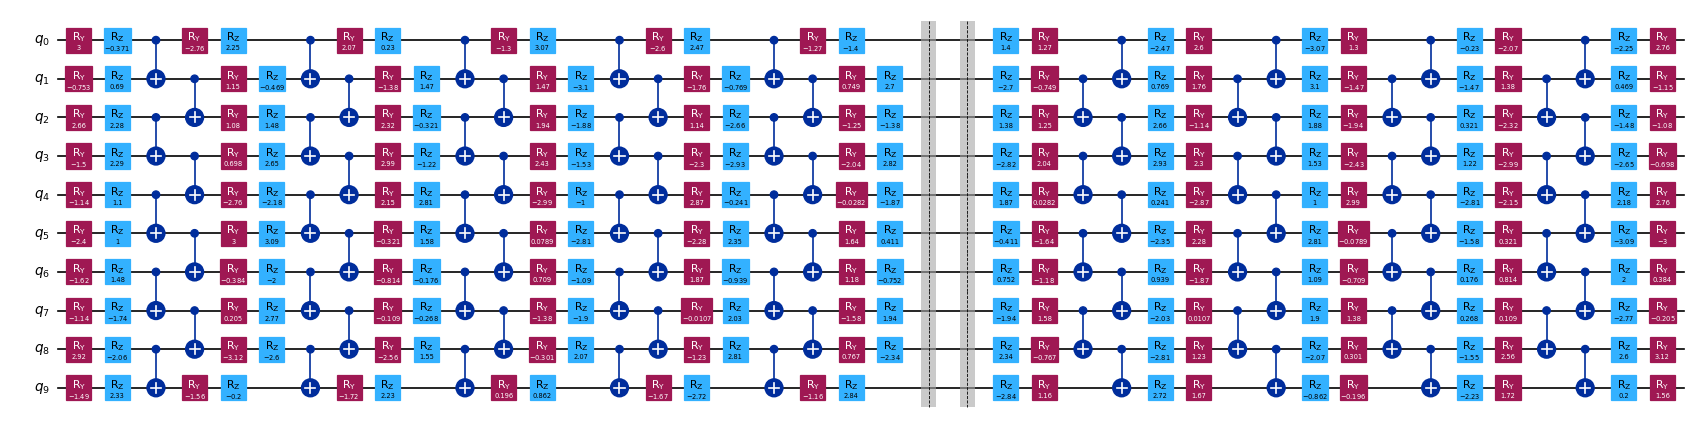

In [52]:
# Backpropagate slices onto the observable
bp_obs, remaining_slices, metadata = backpropagate(
    observable, slices, operator_budget=op_budget
)
# Recombine the slices remaining after backpropagation
bp_circuit = combine_slices(remaining_slices)

print(f"Backpropagated {metadata.num_backpropagated_slices} slices.")
print(
    f"New observable has {len(bp_obs.paulis)} terms, which can be combined into {len(bp_obs.group_commuting(qubit_wise=True))} groups."
)
print(
    f"Note that backpropagating one more slice would result in {metadata.backpropagation_history[-1].num_paulis[0]} terms "
    f"across {metadata.backpropagation_history[-1].num_qwc_groups} groups."
)
print("The remaining circuit after backpropagation looks as follows:")
bp_circuit.draw("mpl", fold=-1, scale=0.6)

Next, we will specify the same problem with the same constraints on the size of the output observable. However, this time, we allow an error budget to each slice using the [setup\_budget](https://quantum.cloud.ibm.com/docs/api/qiskit-addon-obp/utils-truncating#setup_budget) function. Pauli terms with small coefficients will be truncated from each slice until the error budget is filled, and leftover budget will be added to the following slice's budget. Note that in this case, the transformation due to backpropagation is approximate since some of the terms in the operator are truncated.

In order to enable this truncation, we need to setup our error budget like so:

In [53]:
truncation_error_budget = setup_budget(max_error_per_slice=0.005)

Note that by allocating `5e-3` error per slice for truncation, we are able to remove 1 more slice from the circuit, while remaining within the original budget of eight commuting Pauli groups in the observable. By default, `backpropagate` uses the L1 norm of the truncated coefficients to bound the total error incurred from truncation. For other options refer to the [how-to guide on specifying the p\_norm](https://qiskit.github.io/qiskit-addon-obp/how_tos/bound_error_using_p_norm.html).

In this particular example where we have backpropagated four slices, the total truncation error should not exceed `(5e-3 error/slice) * (4 slices) = 2.0e-2`.
For further discussion on distributing an error budget across your slices, check out [this how-to guide](https://qiskit.github.io/qiskit-addon-obp/how_tos/truncate_operator_terms.html).

Backpropagated 4 slices.
New observable has 27 terms, which can be combined into 6 groups.
After truncation, the error in our observable is bounded by 1.780e-02
Note that backpropagating one more slice would result in 117 terms across 32 groups.
The remaining circuit after backpropagation looks as follows:


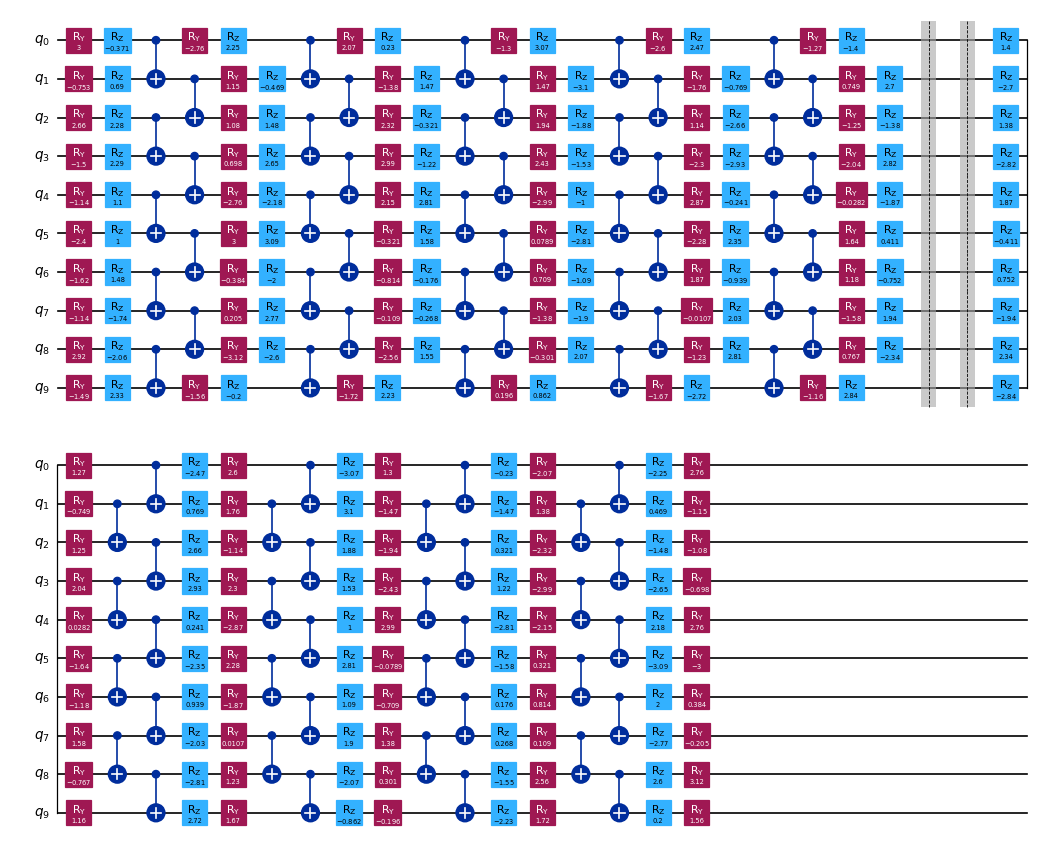

In [54]:
# Run the same experiment but truncate observable terms with small coefficients
bp_obs_trunc, remaining_slices_trunc, metadata = backpropagate(
    observable,
    slices,
    operator_budget=op_budget,
    truncation_error_budget=truncation_error_budget,
)

# Recombine the slices remaining after backpropagation
bp_circuit_trunc = combine_slices(
    remaining_slices_trunc, include_barriers=False
)

print(f"Backpropagated {metadata.num_backpropagated_slices} slices.")
print(
    f"New observable has {len(bp_obs_trunc.paulis)} terms, which can be combined into {len(bp_obs_trunc.group_commuting(qubit_wise=True))} groups.\n"
    f"After truncation, the error in our observable is bounded by {metadata.accumulated_error(0):.3e}"
)
print(
    f"Note that backpropagating one more slice would result in {metadata.backpropagation_history[-1].num_paulis[0]} terms "
    f"across {metadata.backpropagation_history[-1].num_qwc_groups} groups."
)
print("The remaining circuit after backpropagation looks as follows:")
bp_circuit_trunc.draw("mpl", scale=0.6)

We note that in this case, the truncation hasn't allowed us to backpropagate further but it has reduced the number of terms in the new observable. 

#### Now that we have our reduced ansatz and expanded observables, we can transpile our experiments to the backend.

Here we will use an IBM® quantum computer to demonstrate how to transpile to a QPU backend.

In [55]:
# Choose a real backend
service = QiskitRuntimeService(channel='ibm_quantum_platform',)
backend = service.least_busy(min_num_qubits=156)
# print backend details
print(
    f"Name: {backend.name}\n"
    f"Version: {backend.backend_version}\n"
    f"No. of qubits: {backend.num_qubits}\n"
    f"Processor type: {backend.processor_type}\n"
)

Name: ibm_pittsburgh
Version: 1.0.16
No. of qubits: 156
Processor type: {'family': 'Heron', 'revision': '3'}



In [56]:
pm = generate_preset_pass_manager(backend=backend, optimization_level=1)

# Transpile original experiment
circuit_isa = pm.run(mirror_circuit)
observable_isa = observable.apply_layout(circuit_isa.layout)

# Transpile backpropagated experiment
bp_circuit_isa = pm.run(bp_circuit)
bp_obs_isa = bp_obs.apply_layout(bp_circuit_isa.layout)

# Transpile the backpropagated experiment with truncated observable terms
bp_circuit_trunc_isa = pm.run(bp_circuit_trunc)
bp_obs_trunc_isa = bp_obs_trunc.apply_layout(bp_circuit_trunc_isa.layout)

We create the <a href="https://quantum.cloud.ibm.com/docs/guides/primitive-input-output">Primitive Unified Bloc (PUB)</a> for each of the three cases.


In [57]:
pub = (circuit_isa, observable_isa)
bp_pub = (bp_circuit_isa, bp_obs_isa)
bp_trunc_pub = (bp_circuit_trunc_isa, bp_obs_trunc_isa)

### Step 3: Execute using Qiskit primitives

#### Calculate expectation value

Finally, we can run the backpropagated experiments and compare them with the full experiment using the noiseless [StatevectorEstimator](https://quantum.cloud.ibm.com/docs/api/qiskit/qiskit.primitives.StatevectorEstimator).

In [ ]:
ideal_estimator = StatevectorEstimator()

# Run the experiments using Estimator primitive to obtain the exact outcome
result_exact = (
    ideal_estimator.run([(mirror_circuit, observable)]).result()[0].data.evs.item()
)
print(f"Exact expectation value: {result_exact}")

Exact expectation value: 1.0000000000000018


We shall use <a href="https://quantum.cloud.ibm.com/docs/guides/configure-error-mitigation">resilience\_level</a> = 2 for this example.

*Usage estimate: 1 minute 39 seconds on an Heron r2 processor (NOTE: This is an estimate only. Your runtime might vary.)*

In [59]:
options = EstimatorOptions()
options.default_precision = 0.011
options.resilience_level = 2

estimator = EstimatorV2(mode=backend, options=options)
estimator.options.environment.job_tags = ["R2P_LAB"]
job = estimator.run([pub, bp_pub, bp_trunc_pub])

### Step 4: Post-process and return result to desired classical format

In [60]:
result_no_bp = job.result()[0].data.evs.item()
result_bp = job.result()[1].data.evs.item()
result_bp_trunc = job.result()[2].data.evs.item()

std_no_bp = job.result()[0].data.stds.item()
std_bp = job.result()[1].data.stds.item()
std_bp_trunc = job.result()[2].data.stds.item()

In [61]:
print(
    f"Expectation value without backpropagation: {result_no_bp} ± {std_no_bp}"
)
print(f"Backpropagated expectation value: {result_bp} ± {std_bp}")
print(
    f"Backpropagated expectation value with truncation: {result_bp_trunc} ± {std_bp_trunc}"
)

Expectation value without backpropagation: 0.820863915209427 ± 0.014711737405060198
Backpropagated expectation value: 0.8626936604616774 ± 0.014713477364231071
Backpropagated expectation value with truncation: 0.8378567448901483 ± 0.014249681966110312


Text(0, 0.5, '$M_Z$')

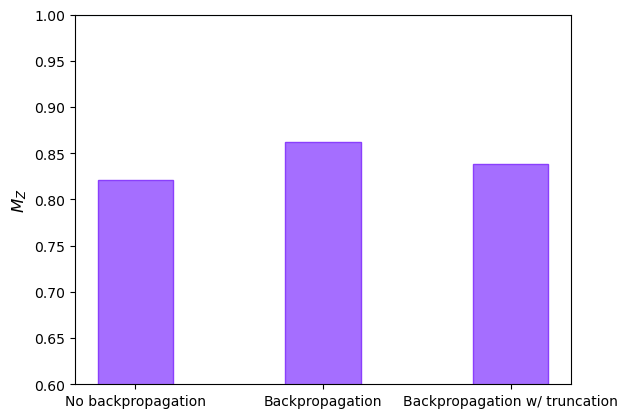

In [62]:
methods = [
    "No backpropagation",
    "Backpropagation",
    "Backpropagation w/ truncation",
]
values = [result_no_bp, result_bp, result_bp_trunc]
stds = [std_no_bp, std_bp, std_bp_trunc]

ax = plt.gca()
plt.bar(methods, values, color="#a56eff", width=0.4, edgecolor="#8a3ffc")
plt.axhline(result_exact)
ax.set_ylim([0.6, 1.0])
#plt.text(0.2, 1., "Exact result")
ax.set_ylabel(r"$M_Z$", fontsize=12)

We can see that the backpropagation technique has helped us to obtain better results at estimating the expectation value of the observable!